# Harmonic oscillators
$$\hat H = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\frac{1}{2}m\omega^2 x^2$$

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
N=1000
device="cuda"
x= torch.linspace(-5,5,N,device=device,)
m=1
hbar=1
omega=10
diff=abs(x[1]-x[2])
row1=torch.ones(size=(N,),device=device)*-1
row2=torch.ones(size=(N-1,),device=device)*2
momenutumPart=1/2*(hbar**2)/m*(torch.diag(row1)+torch.diag(row2,-1)+torch.diag(row2,1))*1/(diff**2)

potentialPart=1/2*m*omega**2*torch.diag(x**2)
hamiltonian=momenutumPart+potentialPart
eigenvalues, eigenvectors=torch.linalg.eigh(hamiltonian)



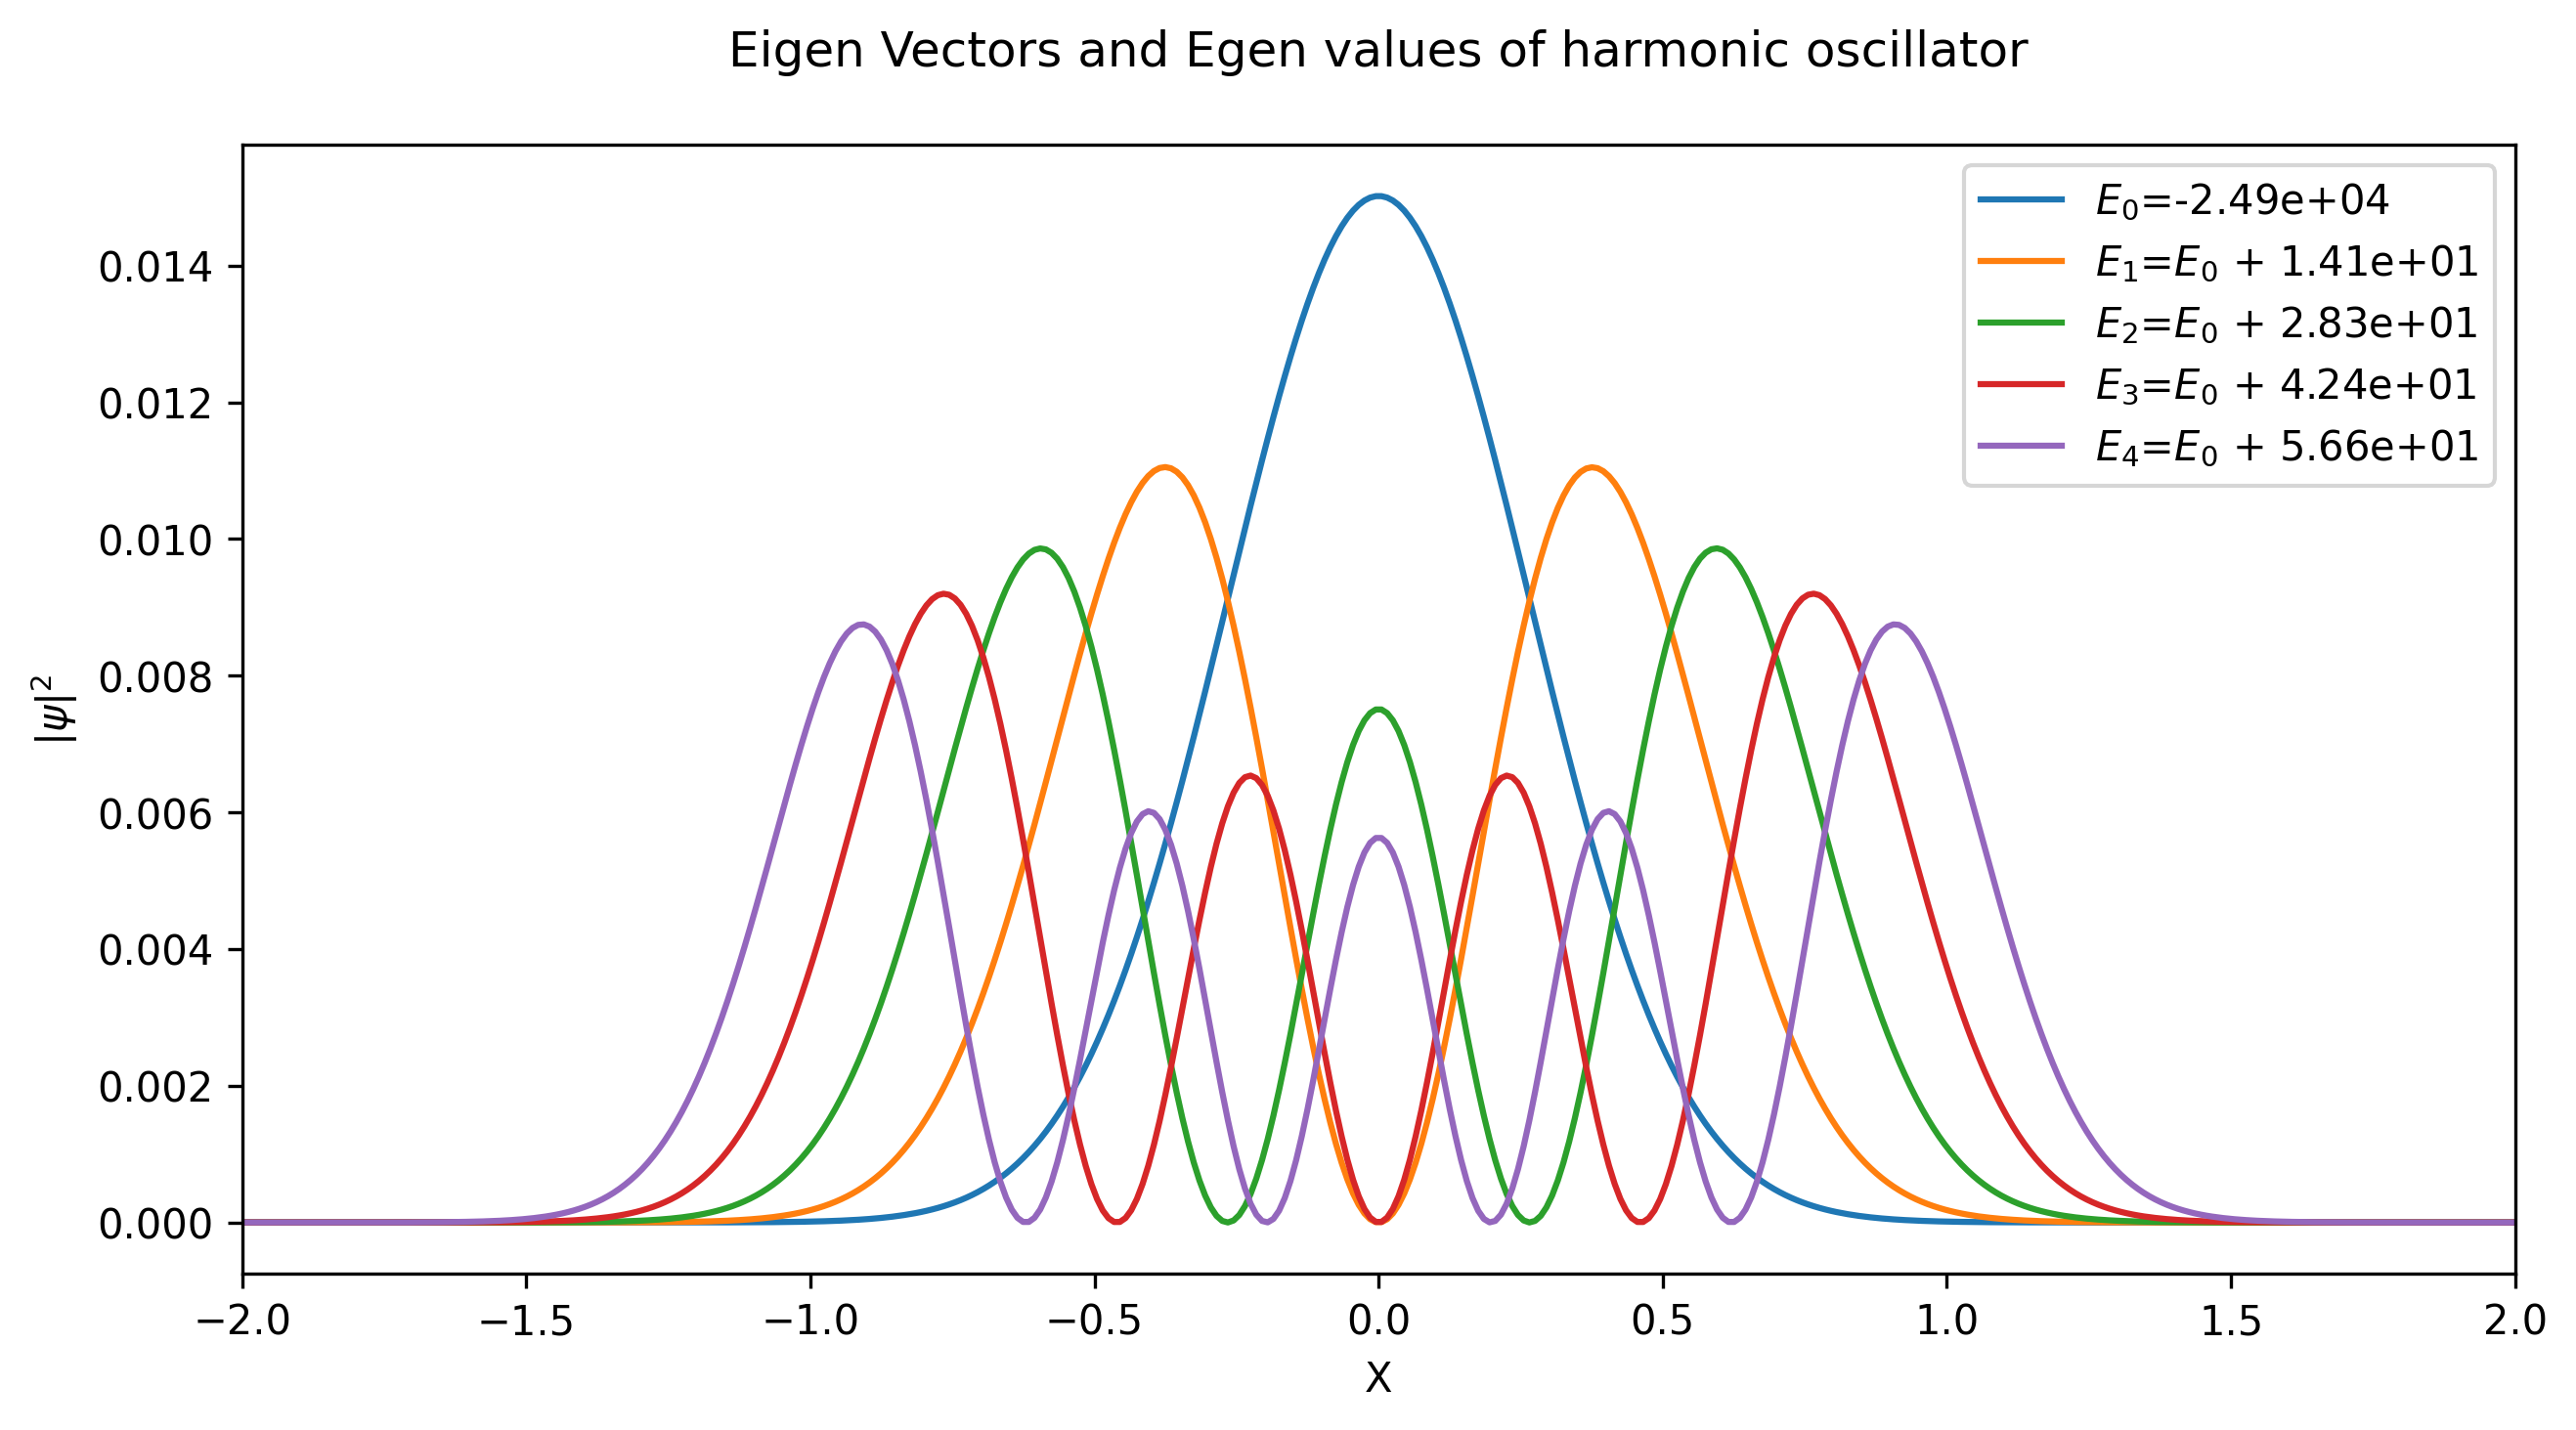

In [9]:
plt.figure(figsize=(10,5),dpi=300)

for i in range(5):
    if(i==0):
        En=f"{eigenvalues[i].item() :.2e}"
    else:
        En=f"$E_0$ + {eigenvalues[i].item()-eigenvalues[0].item() :.2e}"
    psi=torch.abs(eigenvectors[:,i].cpu())
    plt.plot(x.cpu(),psi**2,label=f"$E_{i}$={En}")

plt.legend()
plt.xlim(-2,2)
plt.xlabel("X")
plt.ylabel("$|\\psi|^{2}$")
plt.title("Eigen Vectors and Egen values of harmonic oscillator\n")
plt.show()